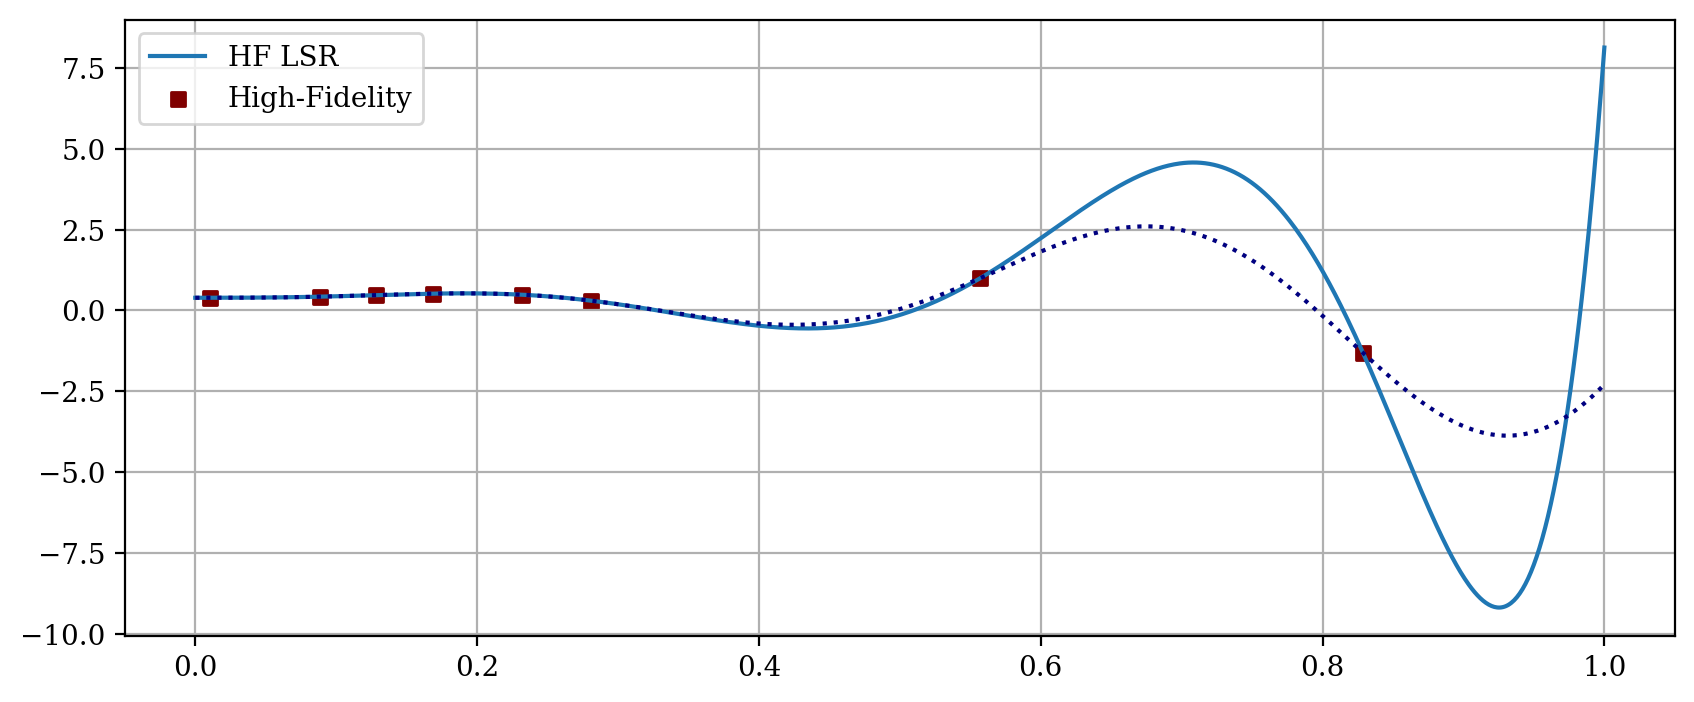

In [3]:
import numpy as np 
import matplotlib.pyplot as plt 
from tqdm import tqdm 
import math 
import jax.numpy as jnp 
from jax.scipy.linalg import cho_solve
from jax import value_and_grad
import jax
from jax import random
jax.config.update("jax_enable_x64", True)
from numpy.random import randn
from numpy import zeros
from copy import deepcopy 

# Plot parameters 
plt.rcParams.update({
    "font.family": "serif",
    'text.latex.preamble': r'\\usepackage{amsmath}',
    'mathtext.fontset': 'cm',
})

# Softplus function for positivity-enforcement
def softplus(x):
    """Softplus activation: log(1 + exp(x))."""
    return jnp.log(1.0 + jnp.exp(x))
def inv_softplus(y):
    """Inverse softplus: maps positive values back to unconstrained space."""
    return jnp.log(jnp.exp(y) - 1.0)

# Functions 
funcs = [
    lambda x: ((5*x**2) * np.sin(12*x))+0.39071933219615607, 
    lambda x: (2*(5*x**2) * np.sin(12*x)+(x**3-0.5*np.sin(3*x-0.5))+4*np.cos(2*x))-1.0072174840335937
]

# creating high and low-fidelity inputs 
n1, n2, n_test = 8, 100, 1000
rng_key = random.PRNGKey(seed = 41)
hi_key, lo_key, test_key = random.split(rng_key, 3)
z1 = random.uniform(hi_key, shape = (n1))
# z1 = jnp.linspace(0,1,n1)
z2 = random.uniform(lo_key, shape = (n2))
ztest = jnp.linspace(0, 1, n_test)

# Creating high and low-fidelity data 
Y11 = funcs[0](z1).ravel()
Y12 = funcs[1](z1).ravel()
Y22 = funcs[1](z2).ravel()
Ytest = funcs[0](ztest).ravel()

# Creating features 
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
scaler, features = StandardScaler(), PolynomialFeatures(degree=8)
X1test = scaler.fit_transform(features.fit_transform(jnp.hstack((
    ztest.reshape(-1,1), funcs[1](ztest).reshape(-1,1)
))))
X11 = scaler.transform(features.transform(jnp.hstack((z1.reshape(-1,1), Y12.reshape(-1,1)))))
X2test = scaler.fit_transform(features.fit_transform(ztest.reshape(-1,1)))
X22 = scaler.transform(features.transform(z2.reshape(-1,1)))
X12 = scaler.transform(features.transform(z1.reshape(-1,1)))

# Plotting the data 
plt.figure(figsize=(10,4), dpi = 200)
what = np.linalg.lstsq(X12, Y11, rcond=1e-13)[0]
plt.plot(ztest, X2test @ what, label = "HF LSR")
plt.scatter(z1.ravel(), Y11.ravel(), s = 25.0, c = 'maroon', label = "High-Fidelity", marker = 's')
plt.plot(ztest.ravel(), Ytest, linestyle = 'dotted', color = 'navy')
plt.grid()
plt.legend()

In [4]:
d1, d2 = X1test.shape[1], X2test.shape[1]

eps = 1e-8

def kl_gaussian(mu_q, mu_p, L_q, L_p):
    k = mu_q.shape[0]
    # ---- log(det Σ) = 2 * sum(log diag(L)) ----
    logdet_q = 2.0 * jnp.sum(jnp.log(jnp.diag(L_q)))
    logdet_p = 2.0 * jnp.sum(jnp.log(jnp.diag(L_p)))
    logdet_ratio = logdet_p - logdet_q

    # ---- trace(Σ_p^{-1} Σ_q) ----
    X = cho_solve((L_p, True), L_q @ L_q.T)  # L_p^{-1} L_q
    trace_term = jnp.trace(X)

    # ---- Mahalanobis distance (μ_p - μ_q)^T Σ_p^{-1} (μ_p - μ_q) ----
    diff = mu_p - mu_q
    v = cho_solve((L_p, True), diff)
    mahalanobis = jnp.dot(diff, v)

    return 0.5 * (trace_term + mahalanobis - k + logdet_ratio)


def likelihood(X, Y, w, noise_var):
    # Computing the misfit between model prediction and data 
    error = (X @ w - Y).ravel() 
    data_fit = jnp.inner(error, error) / noise_var 
    scalar_term = X.shape[0] * jnp.log(2*math.pi*noise_var)
    return -0.5*(data_fit + scalar_term)

def single_likelihood(key, p, q_L):
    # Taking a random parameter sample 
    ws = p['q_mu'] + q_L @ random.normal(key, shape=(d1 + d2))
    # Making the features 
    w1, w2 = ws[:d1], ws[d1:] 
    # Computing high-fidelity likelihood 
    hf_likelihood = likelihood(X11, Y11, w1, softplus(p['noise_var'][0]))
    lf_likelihood = likelihood(
        jnp.vstack((X12, X22)), jnp.concatenate((Y12, Y22)), w2, softplus(p['noise_var'][1]))
    return hf_likelihood + lf_likelihood

def pos_diagonal(M, eps=0.0):
    diag = jnp.diag(M)
    diag_sp = softplus(diag) + eps
    return M - jnp.diag(diag) + jnp.diag(diag_sp)

def neg_elbo(p, N_mc, seed=42):
    # Ensuring positive definiteness of Cholesky factors
    p_L = pos_diagonal(p['p_L'])
    q_L = pos_diagonal(p['q_L'])

    # Generating random numbers 
    key = random.PRNGKey(seed)
    keys = random.split(key, num=N_mc)
    # Obtaining random likelihood draws 
    likelihood_term = jnp.mean(jax.vmap(
        lambda key: single_likelihood(
            key, p, q_L
        )
    )(keys))

    # Computing KL divergence term 
    kl_term = kl_gaussian(p['q_mu'], p['p_mu'], q_L, p_L)

    return -(likelihood_term - kl_term)

# Taking cholesky
w1_lsr = jnp.linalg.lstsq(X11, Y11)[0]
w2_lsr = jnp.linalg.lstsq(X22, Y22)[0]

p = {
    'p_mu':jnp.zeros(d1+d2), # Prior mean 
    'p_L':jnp.diag(inv_softplus(1e1*jnp.ones(d1 + d2))), # Prior Covariance cholesky factor 
    'q_mu': jnp.concatenate((w1_lsr, w2_lsr)), # Variational mean 
    'q_L':jnp.diag(inv_softplus(1e0*jnp.ones(d1+d2))), # Variational cholesky vactor
    'noise_var':inv_softplus(jnp.array([1e-5, 1e-5]))
}

kl_div = kl_gaussian(p['q_mu'], p['p_mu'], pos_diagonal(p['q_L']), pos_diagonal(p['q_L']))
hf_likelihood = likelihood(X11, Y12, p['q_mu'][:d1], softplus(p['noise_var'][0]))
lf_likelihood = likelihood(X22, Y22, p['q_mu'][d1:], softplus(p['noise_var'][0]))

print("KL-Divergence: %.4e" % kl_div)
print("HF-Likelihood: %.4e" % hf_likelihood)
print("LF-Likelihood: %.4e" % lf_likelihood)
N_mc = 100
grad_func = value_and_grad(jax.jit(lambda p: neg_elbo(p, N_mc, seed=42)))
loss, grad = grad_func(p)
print("Initial Loss: %.4e" % loss)
best_loss, best_p = loss, deepcopy(p)

KL-Divergence: 1.0857e+09
HF-Likelihood: -2.3913e+06
LF-Likelihood: -1.8904e+04
Initial Loss: 6.5010e+07


In [13]:
# Making momentum PyTree
p = deepcopy(dict(best_p))
v = jax.tree.map(jnp.zeros_like, p)

epochs, beta = 100000, 0.999
lr = 1e-8
iterator = tqdm(range(epochs))


for iter in iterator:
    loss, grad = grad_func(p)
    iterator.set_postfix_str("Loss: %.4e" % (loss))
    # Updating the parameters
    v = jax.tree.map(lambda v, g: beta * v - lr * g, v,grad)
    p['p_L'] = jnp.tril(p['p_L'] + v['p_L']) 
    p['p_mu'] += v['p_mu'] 
    p['q_mu'] += v['q_mu'] 
    p['q_L'] = jnp.tril(p['q_L'] + v['q_L']) 
    # p['noise_var'] += v['noise_var'] 

    if loss < best_loss: 
        best_loss = loss 
        best_p = deepcopy(dict(p))

  1%|          | 703/100000 [00:06<16:01, 103.25it/s, Loss: 7.5891e+04]


KeyboardInterrupt: 

<>:43: SyntaxWarning: invalid escape sequence '\p'
<>:43: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_3957/2918170736.py:43: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(ztest.ravel(), pred_mean, linestyle = 'dashed', color = 'navy', label = "Multi-Fidelity Mean $\pm 2 \sigma$")


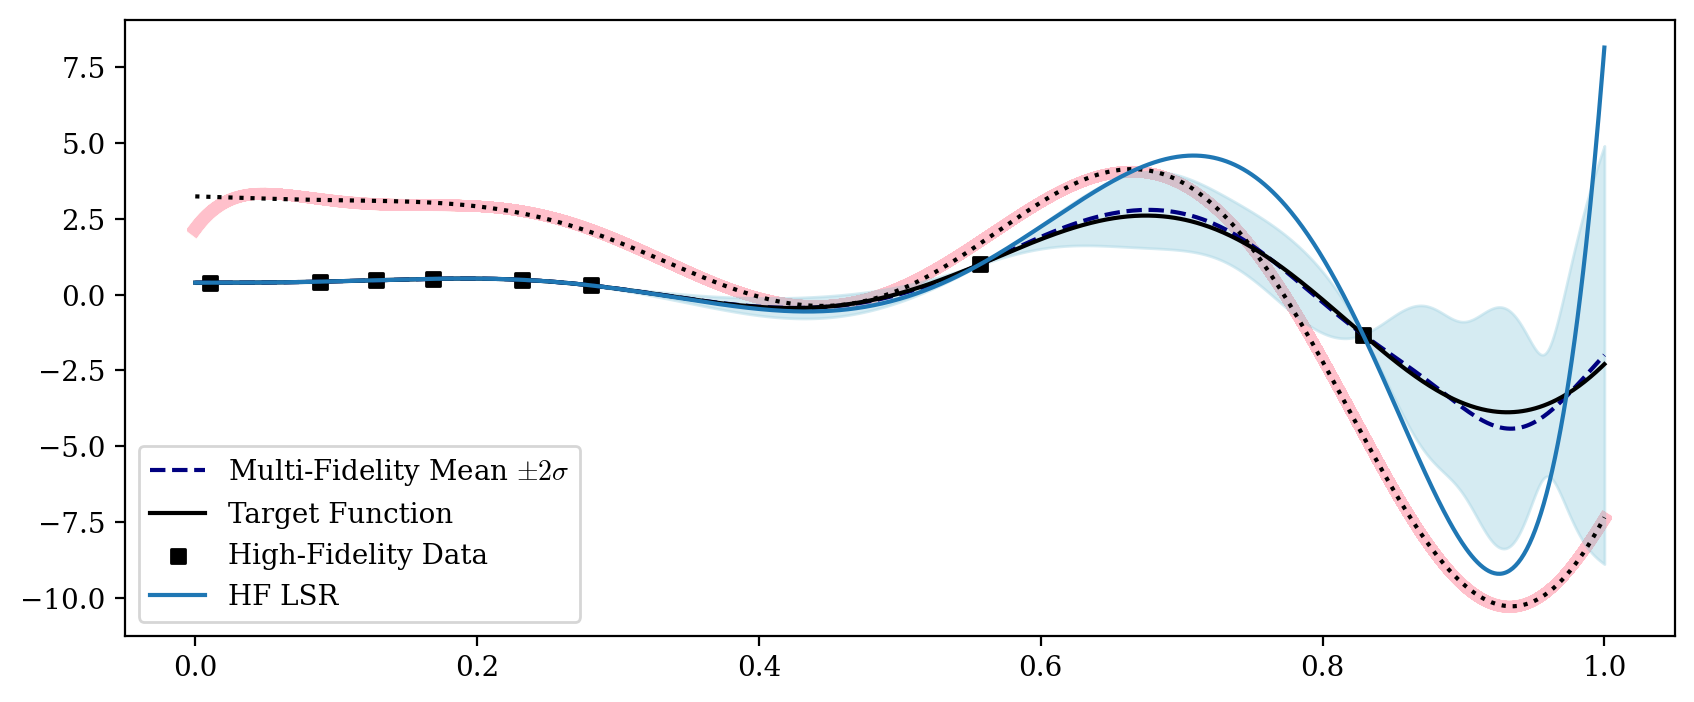

In [14]:
def hf_predict(Xtest, p, N_mc):
    def single_pred(key, Xtest, q_mu, q_L):
        ws = q_mu + q_L @ random.normal(key, shape=(d1+d2))
        return (Xtest @ ws[:d1]).ravel()
    
    key = random.PRNGKey(42)
    keys = random.split(key, N_mc)

    preds = jax.vmap(jax.jit(lambda key: single_pred(
        key, Xtest, p['q_mu'], pos_diagonal(p['q_L'])
    )))(keys)

    return preds

def lf_predict(Xtest, p, N_mc):
    def single_pred(key, Xtest, q_mu, q_L):
        ws = q_mu + q_L @ random.normal(key, shape=(d1+d2))
        return (Xtest @ ws[d1:]).ravel()
    
    key = random.PRNGKey(42)
    keys = random.split(key, N_mc)

    preds = jax.vmap(jax.jit(lambda key: single_pred(
        key, Xtest, p['q_mu'], pos_diagonal(p['q_L'])
    )))(keys)

    return preds

N_mc_test = 250
lf_preds = lf_predict(X2test, best_p, N_mc_test)

plt.figure(figsize=(10,4), dpi = 200)
for i in range(N_mc_test):
    plt.plot(ztest, lf_preds[i,:], linewidth = 4.0, alpha = 0.025, color = 'pink')


w1_mean = p['q_mu'][:d1]
pred_mean = X1test @ w1_mean 
pred_var = X1test @ ((pos_diagonal(p['q_L']) @ pos_diagonal(p['q_L'].T))[:d1, :d1]) @ X1test.T 

pred_conf = 2*jnp.sqrt(jnp.diag(pred_var))
plt.fill_between(ztest, pred_mean - pred_conf, pred_mean + pred_conf, color = 'lightblue', alpha = 0.5)
plt.plot(ztest.ravel(), pred_mean, linestyle = 'dashed', color = 'navy', label = "Multi-Fidelity Mean $\pm 2 \sigma$")
plt.plot(ztest.ravel(), Ytest, linestyle = 'solid', color = 'black', label = "Target Function")
plt.plot(ztest.ravel(), funcs[1](ztest), linestyle = 'dotted', color = 'black')

plt.scatter(z1.ravel(), Y11.ravel(), s = 25.0, c = 'black', label = "High-Fidelity Data", marker = 's')
plt.plot(ztest, X2test @ what, label = "HF LSR")
plt.legend()
# plt.ylim(-7,5)

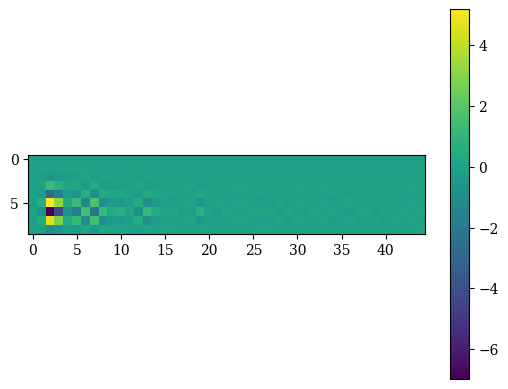

In [12]:
plt.imshow((pos_diagonal(p['p_L']) @ pos_diagonal(p['p_L']))[d1:,:d1])
plt.colorbar()